# Module 8: LDA with SciKit Learn

* DS 5001
* Patrick Maloon

# Set Up

## Configs

In [1]:
n_terms = 4000
n_topics = 30
max_iter = 5
OHCO = ['genre', 'author', 'book', 'chapter', 'para_num']
src_corpus =  'novels-TOKEN.csv'

## Imports

In [2]:
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation as LDA

In [3]:
%matplotlib inline

# Prepare Data

## Convert TOKENS to table of paragraphs

Scikit Learn wants an F1 style corpus. We create onefrom our annotated TOKEN table, keeping only regular nouns.

In [4]:
TOKENS = pd.read_csv(src_corpus)
PARAS = TOKENS[TOKENS.pos.str.match(r'^NNS?$')]\
    .groupby(OHCO).term_str\
    .apply(lambda x: ' '.join(x))\
    .to_frame()\
    .rename(columns={'term_str':'para_str'})

In [5]:
PARAS.head()

para_str
genre author   book            chapter para_num                                                   
d     christie secretadversary 1       1                                                     thing
                                       2                                                      bean
                                       3         people affectionately exit so old misleading a...
                                       4                             not man bun me bit gangway it
                                       5                                    girl assenting towards

## Create Vector Space

We use Scikit Learn's CountVectorizer to convert our F1 corpus of paragraphs into a document-term vector space of word counts.

In [7]:
tfv = CountVectorizer(max_features=n_terms, stop_words='english')
tf = tfv.fit_transform(PARAS.para_str)
TERMS = tfv.get_feature_names_out()

# Generate Model

We run Scikit Learn's [LatentDirichletAllocation algorithm](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.LatentDirichletAllocation.html#sklearn.decomposition.LatentDirichletAllocation) and extract the THETA and PHI tables.

In [8]:
lda = LDA(n_components=n_topics, max_iter=max_iter, learning_offset=50., random_state=0)

## THETA

In [9]:
THETA = pd.DataFrame(lda.fit_transform(tf), index=PARAS.index)
THETA.columns.name = 'topic_id'

In [10]:
THETA.sample(20).style.background_gradient()

## PHI

In [11]:
PHI = pd.DataFrame(lda.components_, columns=TERMS)
PHI.index.name = 'topic_id'
PHI.columns.name  = 'term_str'

In [12]:
PHI.T.head().style.background_gradient()

topic_id,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29
term_str,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
abbess,7.493387,0.033333,0.033333,0.033333,0.033333,0.033333,19.134234,0.033333,0.033333,0.033333,0.033333,0.033333,0.231817,0.033359,0.033333,0.033333,20.933952,3.655222,0.033333,0.033333,0.033333,0.033333,0.033333,1.130444,0.033333,0.564099,7.928643,3.208365,0.033333,0.053144
abbey,0.033333,0.033333,0.033333,0.033333,0.033333,0.033333,0.185104,0.033333,0.033333,0.033367,13.771748,0.033333,0.033333,1.138113,0.033333,1.558584,0.033333,0.033333,0.033333,0.033333,3.032114,3.140611,2.267234,0.033333,0.033333,5.007127,1.422470,0.033333,8.810196,0.033333
abhorrence,1.797736,0.033333,0.033333,0.033333,0.033333,2.381652,12.788564,0.033333,0.033333,0.033333,0.033333,0.033333,0.033333,0.033333,0.033333,0.035406,0.033333,0.033333,0.033333,0.033333,0.033333,0.033333,0.161597,0.035044,0.033333,0.033333,0.033333,0.033333,0.033333,0.033333
abilities,0.033333,0.033333,0.033333,0.033333,1.397168,0.033333,0.033333,0.033333,0.033333,9.867238,0.033333,0.033333,0.033333,0.033333,0.033333,0.797815,0.033333,1.033333,0.033333,0.033333,0.033333,0.071112,1.033333,2.033333,0.033333,0.033333,0.033333,0.033333,0.033333,0.033333
ability,0.033333,0.033333,0.790993,0.033333,0.033333,0.033333,0.132586,5.232984,0.033333,1.817572,0.033333,0.033333,0.033333,0.033333,0.035892,1.454345,0.033333,0.033333,0.033333,5.010461,0.033333,0.033333,0.033333,0.033333,0.033333,0.033333,1.802483,0.033333,0.033333,4.022683


# Inspect Results

## Get Top Terms per Topic

In [14]:
TOPICS = PHI.stack().to_frame().rename(columns={0:'weight'})\
    .groupby('topic_id')\
    .apply(lambda x: 
           x.weight.sort_values(ascending=False)\
               .head(10)\
               .reset_index()\
               .drop('topic_id',axis=1)\
               .term_str)

In [15]:
TOPICS

term_str,0,1,2,3,4,5,6,7,8,9
topic_id,,,,,,,,,,
0,thing,question,things,story,course,idea,death,sure,matter,body
1,hands,dear,man,mr,glass,madam,face,hand,eyes,shoulder
2,lady,tuppence,tone,boy,people,gentleman,did,time,ha,hand
3,time,room,house,way,day,morning,breakfast,door,hour,night
4,time,mind,subject,conversation,place,days,death,evening,earth,knowledge
5,heart,world,man,promise,honour,lady,thought,thoughts,silence,emotion
6,life,heart,affection,friend,death,friends,love,circumstances,time,good
7,father,wife,daughter,man,way,day,house,castle,time,family
8,man,time,thou,help,way,money,house,years,address,place


In [16]:
TOPICS['label'] = TOPICS.apply(lambda x: str(x.name) + ' ' + ' '.join(x), 1)

## Sort Topics by Doc Weight

In [17]:
TOPICS['doc_weight_sum'] = THETA.sum()

<Axes: ylabel='label'>

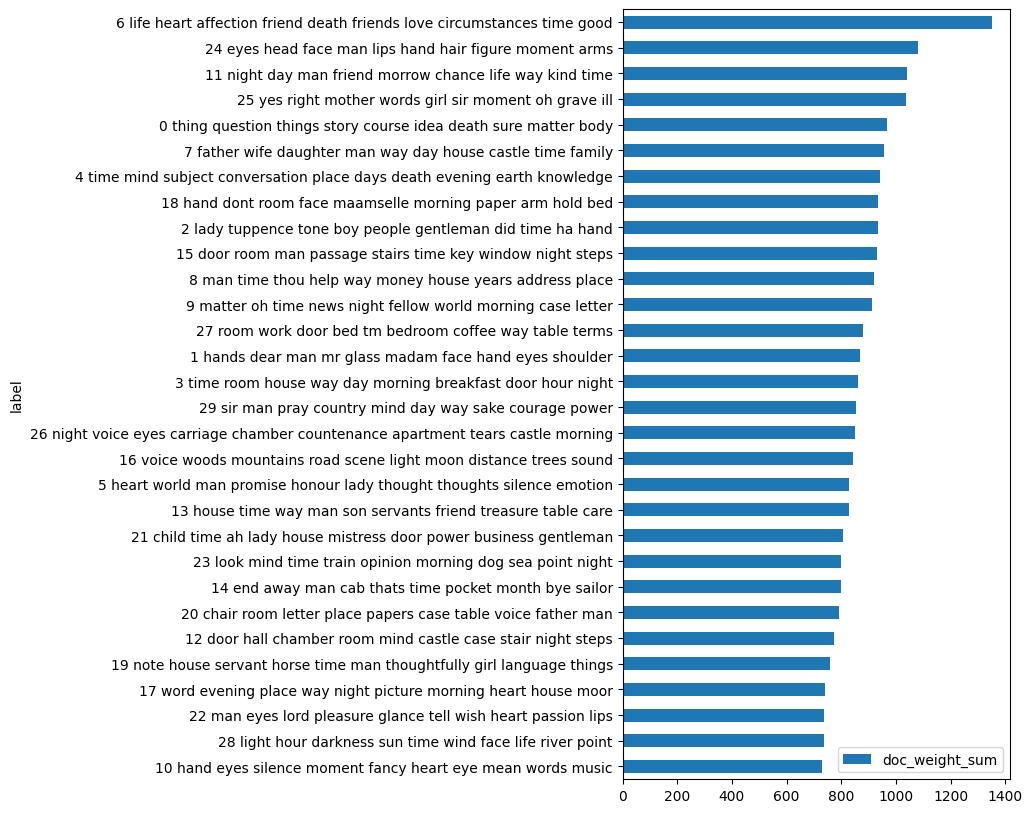

In [18]:
TOPICS.sort_values('doc_weight_sum', ascending=True).plot.barh(y='doc_weight_sum', x='label', figsize=(5,10)) 

## Explore Topics by Genre

In [19]:
topic_cols = [t for t in range(n_topics)]
AUTHORS = THETA.groupby('genre')[topic_cols].mean().T                                            
AUTHORS.index.name = 'topic_id'

In [20]:
AUTHORS.T

topic_id,0,1,2,3,4,5,6,7,8,9,...,20,21,22,23,24,25,26,27,28,29
genre,,,,,,,,,,,,,,,,,,,,,
d,0.043623,0.036467,0.039687,0.038004,0.034199,0.026184,0.027978,0.033052,0.037144,0.041252,...,0.033817,0.033166,0.025809,0.034868,0.041057,0.049246,0.018767,0.035852,0.023129,0.030053
g,0.026822,0.028417,0.029552,0.025720,0.037164,0.037765,0.079794,0.039580,0.031704,0.026306,...,0.024379,0.027509,0.030147,0.024344,0.039897,0.027215,0.049247,0.030457,0.032988,0.034408
nh,0.056981,0.032340,0.044130,0.037213,0.034862,0.027388,0.034541,0.043450,0.033160,0.029922,...,0.041631,0.024093,0.032771,0.034082,0.051097,0.027329,0.015677,0.023355,0.041557,0.039688


In [21]:
AUTHORS['topterms'] = TOPICS[[i for i in range(10)]].apply(lambda x: ' '.join(x), 1)

In [24]:
AUTHORS.sort_values(['g', 'd'], ascending=False).style.background_gradient()

genre,d,g,nh,topterms
topic_id,,,,
6,0.027978,0.079794,0.034541,life heart affection friend death friends love circumstances time good
26,0.018767,0.049247,0.015677,night voice eyes carriage chamber countenance apartment tears castle morning
16,0.022752,0.043019,0.030952,voice woods mountains road scene light moon distance trees sound
12,0.018736,0.042542,0.019670,door hall chamber room mind castle case stair night steps
24,0.041057,0.039897,0.051097,eyes head face man lips hand hair figure moment arms
7,0.033052,0.039580,0.043450,father wife daughter man way day house castle time family
11,0.038843,0.039149,0.050753,night day man friend morrow chance life way kind time
5,0.026184,0.037765,0.027388,heart world man promise honour lady thought thoughts silence emotion
4,0.034199,0.037164,0.034862,time mind subject conversation place days death evening earth knowledge


In [25]:
import plotly_express as px

In [30]:
px.scatter(
    AUTHORS.reset_index(),
    x='g',
    y='d',
    hover_name='topterms',
    text='topic_id'
).update_traces(mode='text')


# Clutser Topics

In [ ]:
import scipy.cluster.hierarchy as sch
from scipy.spatial.distance import pdist
from sklearn.cluster import AgglomerativeClustering
from sklearn.preprocessing import normalize
import matplotlib.pyplot as plt

In [ ]:
def plot_tree(tree, labels):
    plt.figure()
    fig, axes = plt.subplots(figsize=(5, 10))
    dendrogram = sch.dendrogram(tree, labels=labels, orientation="left")
    plt.tick_params(axis='both', which='major', labelsize=14)

In [ ]:
SIMS = pdist(normalize(PHI), metric='euclidean')
TREE = sch.linkage(SIMS, method='ward')

In [ ]:
labels  = ["{}: {}".format(a,b) for a, b in zip(AUTHORS.index,  AUTHORS.topterms.tolist())]

<Figure size 432x288 with 0 Axes>

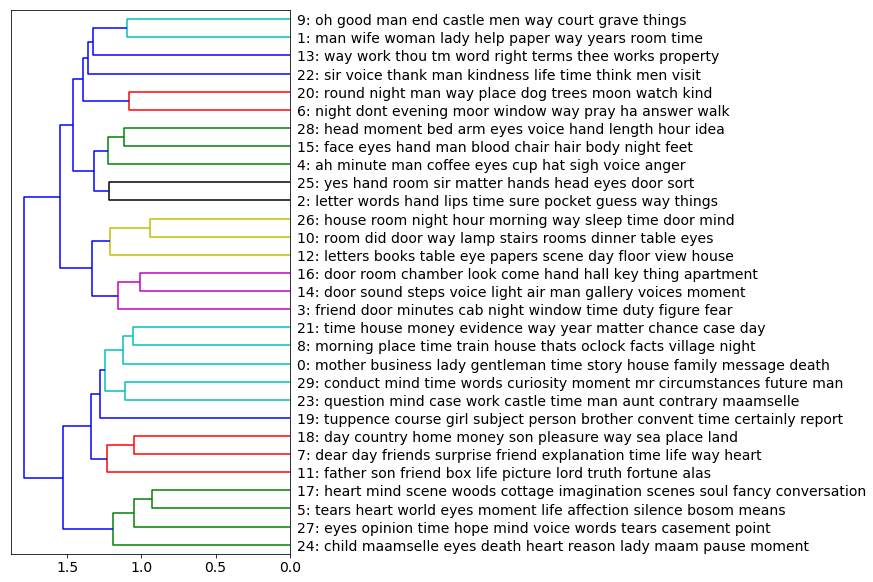

In [ ]:
plot_tree(TREE, labels)

# Interpretation Section:

The topics most associated with the genre 'g' contain words such as "life," "heart," "affection," "love," and "death," as well as descriptive and atmospheric terms like "woods," "mountains," "moon," and "scene." These topics suggest that genre 'g' emphasizes emotional expression, descriptive imagery, and dramatic or atmospheric settings. This genre also included topics such as "eyes," "face," "castle," and "chamber" which relate to physical appearance and dramatic environments. In contrast, the topics most associated with genre `d` include words such as "man," "time," "house," "room," "door," "lady," and "gentleman." These topics reflect everyday life, social roles, and structured environments. The language is more focused on routine interactions, domestic spaces, and practical settings rather than emotional or descriptive elements seen in genre 'g'. Overall, the primary difference between the two genres is that genre `g` emphasizes emotional, descriptive, and atmospheric content, whereas genre `d` focuses more on social structure, daily life, and interpersonal interactions within structured environments.